In [93]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [94]:
df_artistas=pd.read_csv("data/artists.csv")
df_escuchas=pd.read_csv("data/listeners.csv")
df_mas_streams=pd.read_csv("data/Spotify_most_streamed.csv")


In [95]:
df_artistas.head()


,Artist,Streams,Daily,As lead,Solo,As feature
0,Drake,"85,041.3",50.775,"57,252.6","32,681.6","27,788.7"
1,Bad Bunny,"67,533.0",44.820,"40,969.6","23,073.0","26,563.4"
2,Taylor Swift,"57,859.0",85.793,"55,566.7","50,425.7","2,292.4"
3,The Weeknd,"53,665.2",44.437,"42,673.3","31,164.2","10,991.9"
4,Ed Sheeran,"47,907.7",17.506,"42,767.9","33,917.0","5,139.8"


In [96]:
df_escuchas.head()


,Artist,Listeners,Daily Trend,Peak,PkListeners
0,The Weeknd,"107,592,328","-138,880",1,"113,034,886"
1,Taylor Swift,"101,003,302",889,2,"101,003,302"
2,Ed Sheeran,"76,475,126","-68,137",2,"87,934,910"
3,Dua Lipa,"76,421,916","-71,356",4,"77,778,397"
4,Bad Bunny,"76,162,057","-199,052",3,"83,950,570"


In [97]:
df_mas_streams.head()

,Artist and Title,Streams,Daily
0,The Weeknd - Blinding Lights,"3,783,983,806","1,736,378"
1,Ed Sheeran - Shape of You,"3,616,649,759","1,135,140"
2,Lewis Capaldi - Someone You Loved,"2,958,875,491","1,522,093"
3,Post Malone - Sunflower,"2,898,311,408","1,871,177"
4,Tones And I - Dance Monkey,"2,896,024,418","666,818"


In [98]:
print(df_escuchas.columns)
print(df_mas_streams.columns)
print(df_artistas.columns)  

Index(['Artist', 'Listeners', 'Daily Trend', 'Peak', 'PkListeners'], dtype='str')
Index(['Artist and Title', 'Streams', 'Daily'], dtype='str')
Index(['Artist', 'Streams', 'Daily', 'As lead', 'Solo', 'As feature'], dtype='str')


## Limpieza de espacios 

In [99]:
df_artistas.columns = df_artistas.columns.str.strip()
df_escuchas.columns = df_escuchas.columns.str.strip()
df_mas_streams.columns = df_mas_streams.columns.str.strip()

Verificación de valores nulos 

In [100]:
print(df_artistas.isnull().sum())
print(df_escuchas.isnull().sum())
print(df_mas_streams.isnull().sum())

Artist          0
Streams         0
Daily           6
As lead        16
Solo           69
As feature    338
dtype: int64
Artist         0
Listeners      0
Daily Trend    0
Peak           0
PkListeners    0
dtype: int64
Artist and Title    0
Streams             0
Daily               3
dtype: int64


- Se remplazan los valores nulos por 0 en el dataframe de artistas
- Se eliminan las filas con valores nulos en el dataframe de mas_streams

In [101]:
df_artistas = df_artistas.fillna(0)
df_mas_streams=df_mas_streams.dropna()

Separar la columna artist and title del dataframe df_mas_streams para realizar el analisis por separado

In [104]:
df_mas_streams[['Artist','Title']] = df_mas_streams['Artist and Title'].str.split(' - ', n=1, expand=True)

In [105]:
df_mas_streams

,Artist and Title,Streams,Daily,Artist,Title
0,The Weeknd - Blinding Lights,"3,783,983,806","1,736,378",The Weeknd,Blinding Lights
1,Ed Sheeran - Shape of You,"3,616,649,759","1,135,140",Ed Sheeran,Shape of You
2,Lewis Capaldi - Someone You Loved,"2,958,875,491","1,522,093",Lewis Capaldi,Someone You Loved
3,Post Malone - Sunflower,"2,898,311,408","1,871,177",Post Malone,Sunflower
4,Tones And I - Dance Monkey,"2,896,024,418","666,818",Tones And I,Dance Monkey
...,...,...,...,...,...
2495,Richard Marx - Right Here Waiting,"399,549,516","250,073",Richard Marx,Right Here Waiting
2496,The Neighbourhood - You Get Me So High,"399,218,096","617,797",The Neighbourhood,You Get Me So High
2497,Clairo - Bubble Gum,"398,936,748","370,661",Clairo,Bubble Gum
2498,Bing Crosby - White Christmas,"398,725,594","1,250,615",Bing Crosby,White Christmas


Se cambia el tipo de variable de String a int de las columnas Streams y Dayli

In [109]:
df_mas_streams['Streams'] = df_mas_streams['Streams'].str.replace(',', '')
df_mas_streams['Streams'] = pd.to_numeric(df_mas_streams['Streams'])

In [110]:
df_mas_streams['Daily']=df_mas_streams['Daily'].str.replace(',', '')
df_mas_streams['Daily'] = pd.to_numeric(df_mas_streams['Daily'])

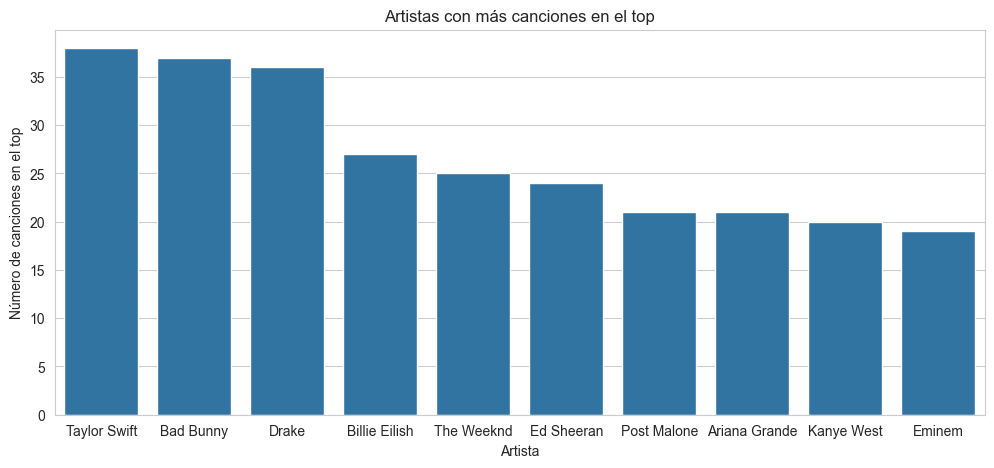

In [131]:
top_artistas=df_mas_streams['Artist'].value_counts().head(10)
plt.figure(figsize=(12,5))

sns.barplot(x=top_artistas.index, y=top_artistas.values)

plt.title("Artistas con más canciones en el top")
plt.xlabel("Artista")
plt.ylabel("Número de canciones en el top")

plt.show()

In [133]:
top_songs = df_mas_streams.sort_values(by='Streams', ascending=False).head(10)


top_songs[['Artist','Title','Streams']]



,Artist,Title,Streams
0,The Weeknd,Blinding Lights,3783983806
1,Ed Sheeran,Shape of You,3616649759
2,Lewis Capaldi,Someone You Loved,2958875491
3,Post Malone,Sunflower,2898311408
4,Tones And I,Dance Monkey,2896024418
5,Drake,One Dance,2770548672
6,Post Malone,rockstar,2763808309
7,The Kid LAROI,STAY,2738183590
8,The Weeknd,Starboy,2658550411
9,Imagine Dragons,Believer,2654895028


In [135]:
df_merge = pd.merge(df_artistas, df_escuchas, on='Artist', how='inner')

In [136]:
df_merge

,Artist,Streams,Daily,As lead,Solo,As feature,Listeners,Daily Trend,Peak,PkListeners
0,Drake,"85,041.3",50.775,"57,252.6","32,681.6","27,788.7","75,371,611","-67,013",6,"76,391,086"
1,Bad Bunny,"67,533.0",44.820,"40,969.6","23,073.0","26,563.4","76,162,057","-199,052",3,"83,950,570"
2,Taylor Swift,"57,859.0",85.793,"55,566.7","50,425.7","2,292.4","101,003,302",889,2,"101,003,302"
3,The Weeknd,"53,665.2",44.437,"42,673.3","31,164.2","10,991.9","107,592,328","-138,880",1,"113,034,886"
4,Ed Sheeran,"47,907.7",17.506,"42,767.9","33,917.0","5,139.8","76,475,126","-68,137",2,"87,934,910"
...,...,...,...,...,...,...,...,...,...,...
1925,Joan Jett & the Blackhearts,730.9,0.591,691.5,687.5,39.4,"7,580,144","37,452",1214,"7,580,144"
1926,Billy Ocean,730.3,0.439,730.3,729.9,0,"5,054,340","8,890",1985,"5,065,809"
1927,Majestic,729.9,0.489,625.0,37.9,104.9,"6,148,938","6,678",1353,"6,424,865"
1928,"Grover Washington, Jr.",729.9,0.466,727.5,208.1,2.4,"5,685,091","15,398",1459,"6,084,681"


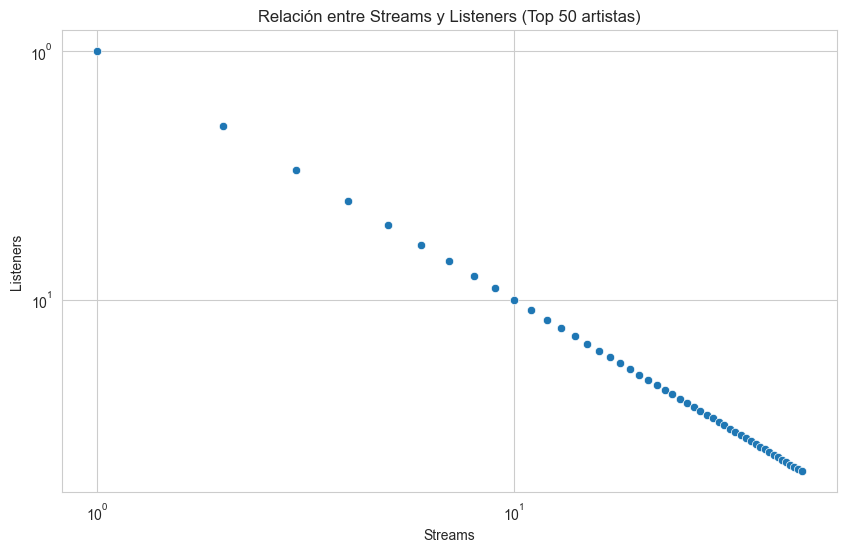

In [145]:
top_artists = df_merge.sort_values(by='Streams', ascending=False).head(50)

plt.figure(figsize=(10,6))

sns.scatterplot(data=top_artists, x='Streams', y='Listeners')

plt.xscale('log')
plt.yscale('log')

plt.title("Relación entre Streams y Listeners (Top 50 artistas)")


plt.show()

Existe una relación positiva entre el número total de streams
y la cantidad de oyentes mensuales. Los artistas con mayor
número de reproducciones tienden a tener más oyentes activos,
aunque algunos artistas logran altos streams históricos
sin mantener el mismo nivel de oyentes actuales.

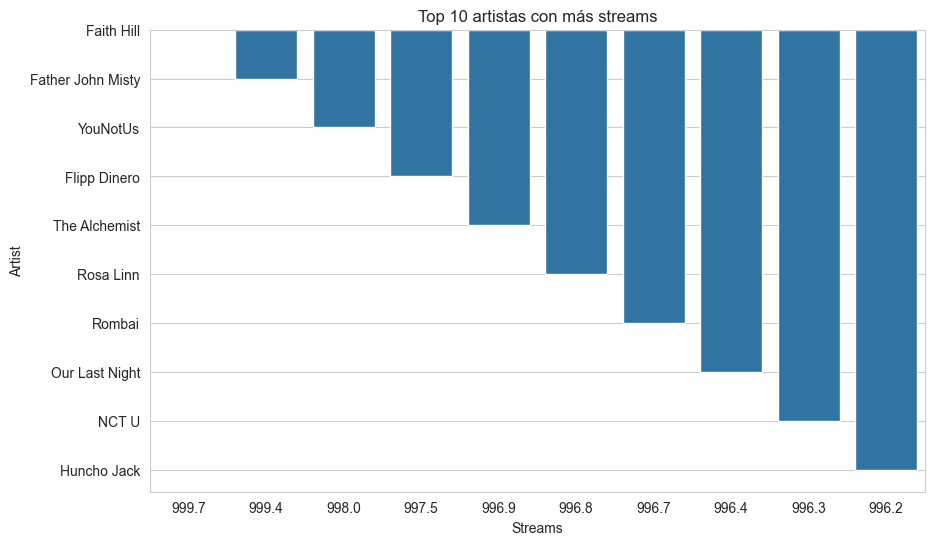

In [146]:
top_stream_artists = df_artistas.sort_values(by='Streams', ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(data=top_stream_artists, x='Streams', y='Artist')

plt.title("Top 10 artistas con más streams")

plt.show()

In [149]:
df_merge.info()

<class 'pandas.DataFrame'>
RangeIndex: 1930 entries, 0 to 1929
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Artist       1930 non-null   str    
 1   Streams      1930 non-null   str    
 2   Daily        1930 non-null   float64
 3   As lead      1930 non-null   object 
 4   Solo         1930 non-null   object 
 5   As feature   1930 non-null   object 
 6   Listeners    1930 non-null   str    
 7   Daily Trend  1930 non-null   str    
 8   Peak         1930 non-null   int64  
 9   PkListeners  1930 non-null   str    
dtypes: float64(1), int64(1), object(3), str(5)
memory usage: 150.9+ KB


In [150]:

# limpiar columnas con números
cols = ['Streams', 'As lead', 'Solo', 'As feature', 'Listeners', 'Daily Trend', 'PkListeners']

for col in cols:
    df_merge[col] = df_merge[col].astype(str).str.replace(',', '', regex=False)

# convertir a números
df_merge['Streams'] = pd.to_numeric(df_merge['Streams'], errors='coerce')
df_merge['As lead'] = pd.to_numeric(df_merge['As lead'], errors='coerce')
df_merge['Solo'] = pd.to_numeric(df_merge['Solo'], errors='coerce')
df_merge['As feature'] = pd.to_numeric(df_merge['As feature'], errors='coerce')
df_merge['Listeners'] = pd.to_numeric(df_merge['Listeners'], errors='coerce')
df_merge['Daily Trend'] = pd.to_numeric(df_merge['Daily Trend'], errors='coerce')
df_merge['PkListeners'] = pd.to_numeric(df_merge['PkListeners'], errors='coerce')

In [151]:
df_merge.info()

<class 'pandas.DataFrame'>
RangeIndex: 1930 entries, 0 to 1929
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Artist       1930 non-null   str    
 1   Streams      1930 non-null   float64
 2   Daily        1930 non-null   float64
 3   As lead      1930 non-null   float64
 4   Solo         1930 non-null   float64
 5   As feature   1930 non-null   float64
 6   Listeners    1930 non-null   int64  
 7   Daily Trend  1930 non-null   int64  
 8   Peak         1930 non-null   int64  
 9   PkListeners  1930 non-null   int64  
dtypes: float64(5), int64(4), str(1)
memory usage: 150.9 KB


In [152]:
df_merge[['Streams','Listeners']].corr()

,Streams,Listeners
Streams,1.000000,0.839121
Listeners,0.839121,1.000000


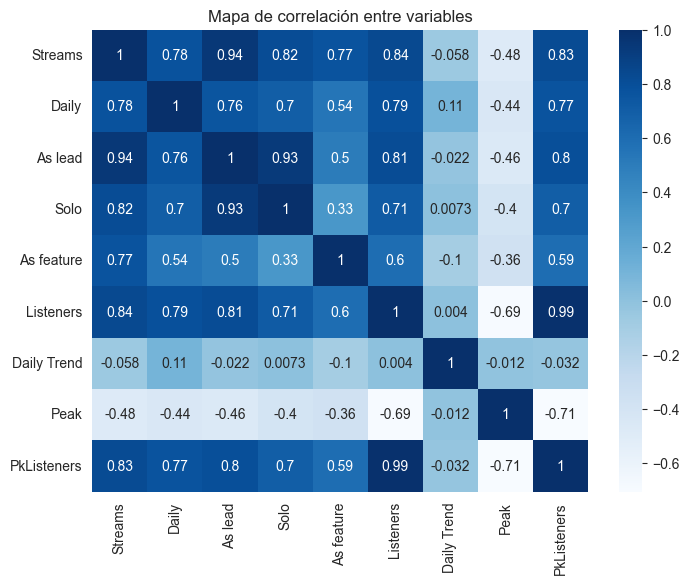

In [153]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df_merge.select_dtypes(include='number').corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Mapa de correlación entre variables")
plt.show()

In [154]:
df_merge[['Solo','As lead','As feature','Streams']].corr()

,Solo,As lead,As feature,Streams
Solo,1.000000,0.927811,0.325667,0.816539
As lead,0.927811,1.000000,0.504380,0.940450
As feature,0.325667,0.504380,1.000000,0.767869
Streams,0.816539,0.940450,0.767869,1.000000
